In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Packages
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, f1_score, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
df = pd.read_csv("Customer_Churn_data.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.shape

(7043, 21)

In [7]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Checking for the duplicates

In [9]:
df.duplicated().sum()

np.int64(0)

**Observation:**
    No  duplicates found in the dataset

### Checking for Null Values

In [10]:
round((df.isnull().sum()/len(df.index)*100),2)

,0
customerID,0.00
gender,0.00
SeniorCitizen,0.00
Partner,0.00
Dependents,0.00
tenure,0.00
PhoneService,0.00
MultipleLines,0.00
InternetService,0.00
OnlineSecurity,0.00


In [7]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [8]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

**Observation:** :  We found that <u>0.16 % Null values in TotalCharge columns</u>. Hence i filled the null values with **Median** of TotalCharges

### Removing Outliers from the numeric columns

In [9]:
def remove_outliers(data, columns):
    for column in columns:
        if column in data.columns:
            Q1 = data[column].quantile(0.25)
            Q3 = data[column].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            data = data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]
    return data

In [10]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df_remove = remove_outliers(df,num_cols)

### Dropping the Customer ID column as its not predictive

In [11]:
df.drop('customerID',axis=1,inplace = True)

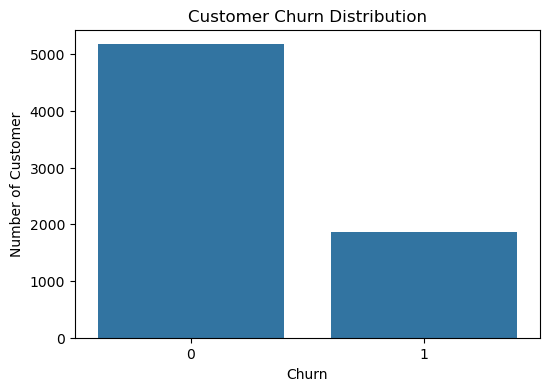

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data = df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customer")

plt.show()

#### Converting Churn from categorical (Yes/No) to numeric (1/0) is a fundamental requirement for most machine-learning algorithms

In [12]:
df['Churn'] = df['Churn'].map({'Yes':1,'No':0})

In [13]:
df = pd.get_dummies(df, drop_first=True)

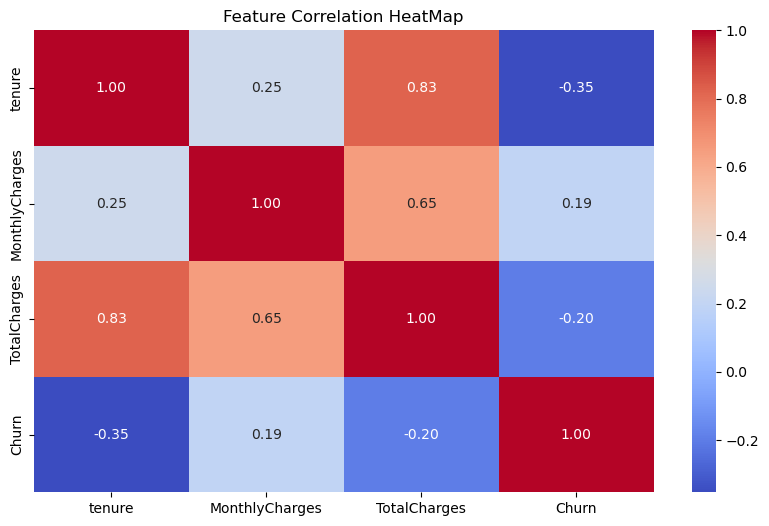

In [25]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df[['tenure','MonthlyCharges','TotalCharges','Churn']].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Feature Correlation HeatMap")
plt.show()

### Obeservation: 
The correlation heatmap shows relationships between numeric features in the dataset. Tenure and total charges have a strong positive correlation (0.83), indicating that customers who stay longer accumulate higher billing amounts. Tenure also shows a moderate negative correlation with churn (-0.35), suggesting that long-term customers are less likely to leave. Monthly charges have a weak positive correlation with churn (0.19), which may indicate that customers with higher subscription costs have a slightly higher likelihood of leaving the service.

### Model Training


In [23]:
# Data splitting for training the model
y = df['Churn']
x = df.drop('Churn',axis=1)

In [21]:
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size = 0.2, random_state=42, stratify=y)

In [22]:
y.value_counts(normalize=True)

Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

### Scaling
Feature scaling was applied to the numerical variables using standardization to ensure all features were on a comparable scale, which improved model convergence, stability, and the reliability of coefficient estimates in the logistic regression model.

In [21]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Logistic RegressionModel building

In [22]:
log_reg = LogisticRegression(max_iter=5000,class_weight='balanced', C=0.5 ,random_state=42)
log_reg.fit(X_train_scaled, Y_train)

LogisticRegression(C=0.5, class_weight='balanced', max_iter=5000,
                   random_state=42)

In [23]:
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:,1]

In [24]:
print("Confusion Matrix:\n", confusion_matrix(Y_test, y_pred))
print("\nClassification Report:\n", classification_report(Y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(Y_test, y_pred_proba))

Confusion Matrix:
 [[746 289]
 [ 81 293]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC Score: 0.8413108062724431


The model achieved a recall of **0.78** for churn customers, indicating that it correctly identifies most customers who are likely to leave. Recall was prioritized because failing to identify a churn customer directly impacts business revenue. The **ROC-AUC score of 0.84** demonstrates strong class discrimination across thresholds.

### **New Data Prediction**

In [25]:
new_customer = pd.DataFrame({
    'gender': ['Female'],
    'SeniorCitizen': [0],
    'tenure': [12],
    'PhoneService': ['Yes'],
    'InternetService': ['Fiber optic'],
    'OnlineSecurity': ['No'],
    'OnlineBackup': ['Yes'],
    'DeviceProtection': ['No'],
    'TechSupport': ['No'],
    'StreamingTV': ['Yes'],
    'StreamingMovies': ['Yes'],
    'Contract': ['Month-to-month'],
    'PaperlessBilling': ['Yes'],
    'PaymentMethod': ['Electronic check'],
    'MonthlyCharges': [85.5],
    'TotalCharges': [1020.5]
})

In [29]:
# Combine new customer with training data to ensure consistent encoding
combined_df = pd.concat([X_train, new_customer], axis=0)

# Apply one-hot encoding
combined_encoded = pd.get_dummies(combined_df, drop_first=True)

# Extract only the new customer row
new_customer_encoded = combined_encoded.tail(1)


In [30]:
# Align columns with training data
new_customer_encoded = new_customer_encoded.reindex(columns=X_train.columns, fill_value=0)

# Scale new customer data
new_customer_scaled = scaler.transform(new_customer_encoded)



In [31]:
print("Churn Prediction:", "Yes" if churn_prediction == 1 else "No")
print("Churn Probability:", round(churn_probability, 2))

Churn Prediction: Yes
Churn Probability: 0.88


**Conclusion**

In this project, a **customer churn prediction** model was developed using demographic, account, and service-related data to identify customers at risk of discontinuing services. After performing **data exploration, preprocessing, encoding of categorical variables, and feature scaling**, a Logistic Regression model was trained and optimized to handle class imbalance effectively.

The optimized model demonstrated strong performance in identifying churn customers, with recall and F1-score prioritized over accuracy due to the imbalanced nature of the dataset. Evaluation metrics such as **<u>confusion matrix, precision, recall, F1-score, and ROC-AUC confirmed</u>** the model’s ability to distinguish between churn and non-churn customers reliably.

The model achieved a churn recall of **78%**, correctly identifying most churn customers, with an overall accuracy of 74%. The **ROC-AUC** score of **0.84** indicates strong separation between churn and non-churn customers across different thresholds

Additionally, the model was successfully used to **predict churn for new, unseen customer data**, enabling proactive identification of high-risk customers. These predictions can help the business design targeted retention strategies, such as personalized offers, improved customer support, and contract-based incentives.

